# 🤖 Python for AI: Complete Data Science Pipeline

## 🎯 Module Overview

Welcome to the comprehensive Python for AI notebook! This module takes you through the complete journey from raw messy data to trained machine learning models.

### What You'll Master

**Part 1: Data Loading & Inspection** 📂
- Loading from multiple formats (CSV, Excel, JSON)
- Inspecting data structure and quality

**Part 2: Data Cleaning & Preprocessing** 🧹
- Handling missing values (drop, fill, impute)
- Removing duplicates
- Detecting and handling outliers (IQR method)
- Data type conversions

**Part 3: Data Visualization with Matplotlib** 📊
- Line plots (time series trends)
- Bar charts (categorical comparisons)
- Histograms (distributions)
- Box plots (outlier detection)
- Scatter plots (relationships)

**Part 4: Machine Learning Basics** 🎓
- Linear Regression (predicting continuous values)
- Logistic Regression (classification)
- Model training, evaluation, and persistence

---

## 💡 Why This Matters for AI

> "Garbage in, garbage out" - The quality of your ML models depends entirely on clean, well-prepared data.

Real-world AI projects spend **80% of time** on data preparation and only **20% on modeling**. Mastering these skills is essential for:
- 🔍 Building reliable AI applications
- 📈 Creating meaningful visualizations
- 🎯 Training accurate machine learning models
- 💼 Succeeding in data science roles

---

## 📋 Prerequisites

**Required Knowledge:**
- Python basics (variables, data types, functions)
- Basic understanding of DataFrames (recommended: complete Module 3)

**Required Libraries:**
```python
pandas       # Data manipulation
matplotlib   # Visualization
numpy        # Numerical operations
scikit-learn # Machine learning
openpyxl     # Excel file support
```

---

## 🚀 Learning Path

```
Raw Data → Clean Data → Visualize Insights → Build Models → Make Predictions
```

**Let's begin your AI journey!** 🎊


## 1. Loading Data

### 1.1 Reading CSV Files

CSV (Comma Separated Values) is the most common file format for data storage. Pandas provides `read_csv()` to load this data into a DataFrame.


---

# 📂 Part 1: Loading Data from Multiple Sources

## 1.1 Reading CSV Files

**CSV (Comma-Separated Values)** is the most common file format for data storage. It's:
- ✅ Simple and lightweight
- ✅ Compatible with all data tools
- ✅ Easy to create and edit

**Pandas Function:** `pd.read_csv(filename)`

**Pro Tip:** CSV is the standard for data exchange in data science. Always start by checking if your data source provides CSV format!


In [ ]:
# Import pandas library for data manipulation
import pandas as pd

# Load CSV file into a DataFrame
# A DataFrame is a 2D table with rows and columns (like Excel)
df_csv = pd.read_csv("sales_data.csv")

# Display first 5 rows to inspect the data structure
# Always inspect your data before processing!
df_csv.head()


---

### 1.2 Reading Excel Files

**Excel files** (`.xlsx`, `.xls`) are widely used in business environments. They support:
- 📊 Multiple sheets in one file
- 🎨 Formatted data and formulas
- 💼 Common in corporate settings

**Requirements:**
- Must install `openpyxl` library: `pip install openpyxl`

**Pandas Function:** `pd.read_excel(filename, sheet_name='SheetName')`

**When to use:** When working with business data, financial reports, or multi-sheet datasets.


In [2]:
df_excel = pd.read_excel('student_scores.xlsx')

df_excel.head()

,Name,Subject,Score,Hours_Studied
0,Student_51,History,11.0,9.8
1,Student_141,History,20.0,9.3
2,Student_168,Science,10.0,7.3
3,Student_109,Science,43.0,9.6
4,Student_207,Science,57.0,12.0


In [ ]:
# Load Excel file (requires openpyxl library)
# By default, reads the first sheet
df_excel = pd.read_excel('student_scores.xlsx')

# Preview the data
df_excel.head()


---

### 1.3 Reading JSON Files

**JSON (JavaScript Object Notation)** is the standard format for:
- 🌐 Web APIs and REST services
- 📱 Mobile app data
- 🔄 Data exchange between systems

**Pandas Function:** `pd.read_json(filename)`

**Key Features:**
- Handles nested/hierarchical data
- Common in modern web applications
- Can be flattened for analysis

**Use Case:** When pulling data from APIs, NoSQL databases, or web scraping.


In [ ]:
# Load JSON file into DataFrame
# Pandas automatically flattens simple JSON structures
df_json = pd.read_json("data.json")

# Inspect the structure
df_json.head()


---

# 🧹 Part 2: Data Cleaning - Handling Missing Values

## Why Missing Values Matter

Real-world data is **rarely perfect**. Missing values can occur due to:
- ❌ Data collection errors
- ❌ System failures
- ❌ Survey non-responses
- ❌ Data integration issues

**Impact on AI Models:**
- Most ML algorithms **cannot handle** missing values
- Ignoring them can lead to **biased results**
- Proper handling improves **model accuracy**

**Represented as:** `NaN` (Not a Number) or `None` in pandas.

---


### 2.1 Detecting Missing Values

**Step 1:** Always identify WHERE and HOW MANY missing values exist.

**Key Functions:**
- `.isna()` or `.isnull()` - Returns True/False for each cell
- `.sum()` - Counts missing values per column

**Workflow:**
```python
df.isna()          # Boolean mask (True = missing)
df.isna().sum()    # Count per column
```

**Decision Making:** If >50% of a column is missing, consider dropping the column entirely.


In [ ]:
# Count missing values in each column of the dataset
# This gives us a clear picture of data quality
missing_counts = df_csv.isna().sum()

# Display the counts
# Columns with 0 have no missing values (clean!)
# High counts indicate problematic columns
missing_counts


---

### 2.2 Strategies for Handling Missing Values

You have **3 main approaches**:

#### 🗑️ Strategy 1: Drop (Remove)
- **When:** Missing values are rare (<5%) and dataset is large
- **Function:** `.dropna()`
- **Pros:** Simple, preserves data integrity
- **Cons:** Loses information, reduces dataset size

#### ✏️ Strategy 2: Fill with Constant
- **When:** Missing values have logical defaults (e.g., 0 for quantity)
- **Function:** `.fillna(value)`
- **Pros:** Preserves dataset size
- **Cons:** May introduce bias

#### 📊 Strategy 3: Impute (Statistical Fill)
- **When:** Data is numeric and shows patterns
- **Methods:**
  - `fillna(df.mean())` - Use average (normal distribution)
  - `fillna(df.median())` - Use middle value (skewed data)
  - `fillna(df.mode()[0])` - Use most common (categorical)
  - `fillna(method='ffill')` - Use previous value (time series)
- **Pros:** Statistically sound, preserves distributions
- **Cons:** Can hide patterns, needs domain knowledge

**Pro Tip:** Combine strategies! Drop if <5%, impute if 5-30%, consider dropping column if >30%.


In [ ]:
# OPTION 1: Drop all rows with ANY missing values
# Use when: Dataset is large and missing values are minimal
df_clean = df_csv.dropna()

# Result: Only complete rows remain
# Check before/after size: df_csv.shape vs df_clean.shape


In [ ]:
# OPTION 2: Fill all missing values with 0
# Use when: Zero is a meaningful default (e.g., counts, quantities)
df_filled = df_csv.fillna(0)

# Result: All NaN values replaced with 0
# Warning: May not make sense for all columns (e.g., prices, dates)


In [ ]:
# OPTION 3: Forward Fill - Propagate last valid value
# Use when: Time-series data where values change slowly
# Example: Stock prices, sensor readings
df_ffill = df_csv.fillna(method="ffill")

# How it works:
# [10, NaN, NaN, 20] → [10, 10, 10, 20]
# Each NaN gets filled with the value above it


In [ ]:
# OPTION 4: Fill numeric columns with their MEAN
# Use when: Data is normally distributed (bell curve)

# Check for missing values in 'Score' column
missing_in_score = df_excel.isna().sum()
print("Missing values per column:\n", missing_in_score)


In [ ]:
# Calculate the mean of the 'Score' column
# Mean = average value, good for numeric data
score_mean = df_excel["Score"].mean()

print(f"Average Score: {score_mean:.2f}")
# This value will replace all NaN values in 'Score'
score_mean


In [ ]:
# Fill missing scores with the calculated mean
# In-place operation: directly modifies the 'Score' column
df_excel['Score'] = df_excel['Score'].fillna(df_excel["Score"].mean())

# Verify: Check if any missing values remain
# df_excel['Score'].isna().sum() should return 0


### Data Cleaning

## 3. Creating Clean Data: Removing Duplicates

Duplicate rows can skew analysis. We use `drop_duplicates()` to clean them.


In [11]:
# Remove duplicate rows, keeping the first occurrence

df_csv.drop_duplicates(keep = "first") # Keep first occurance

,Date,Product,Category,Quantity,Price,Discount
0,2023-04-13,Product_40,Books,15.0,483.59,0.29
1,2023-06-29,Product_83,Books,NaN,116.03,0.29
2,2023-04-03,Product_42,Electronics,15.0,333.21,0.12
3,2023-01-15,Product_41,Clothing,14.0,372.24,0.22
4,2023-04-17,Product_6,Clothing,9.0,424.97,0.10
...,...,...,...,...,...,...
995,2023-04-21,Product_88,Toys,6.0,288.66,0.22
996,2023-04-21,Product_41,Books,3.0,165.98,0.16
997,2023-02-03,Product_17,Clothing,19.0,24.44,0.27
998,2023-04-21,Product_76,Books,15.0,139.64,0.17


In [12]:
# Remove duplicate rows, keeping the first occurrence

df_csv.drop_duplicates(keep = "last") # Keep last occurance

,Date,Product,Category,Quantity,Price,Discount
0,2023-04-13,Product_40,Books,15.0,483.59,0.29
1,2023-06-29,Product_83,Books,NaN,116.03,0.29
2,2023-04-03,Product_42,Electronics,15.0,333.21,0.12
3,2023-01-15,Product_41,Clothing,14.0,372.24,0.22
4,2023-04-17,Product_6,Clothing,9.0,424.97,0.10
...,...,...,...,...,...,...
995,2023-04-21,Product_88,Toys,6.0,288.66,0.22
996,2023-04-21,Product_41,Books,3.0,165.98,0.16
997,2023-02-03,Product_17,Clothing,19.0,24.44,0.27
998,2023-04-21,Product_76,Books,15.0,139.64,0.17


In [13]:
# Remove duplicate rows, keeping the first occurrence

df_csv.drop_duplicates(keep = False) # Remove *all* duplicates

,Date,Product,Category,Quantity,Price,Discount
0,2023-04-13,Product_40,Books,15.0,483.59,0.29
1,2023-06-29,Product_83,Books,NaN,116.03,0.29
2,2023-04-03,Product_42,Electronics,15.0,333.21,0.12
3,2023-01-15,Product_41,Clothing,14.0,372.24,0.22
4,2023-04-17,Product_6,Clothing,9.0,424.97,0.10
...,...,...,...,...,...,...
995,2023-04-21,Product_88,Toys,6.0,288.66,0.22
996,2023-04-21,Product_41,Books,3.0,165.98,0.16
997,2023-02-03,Product_17,Clothing,19.0,24.44,0.27
998,2023-04-21,Product_76,Books,15.0,139.64,0.17


### Remove duplicates based on specific columns

In [14]:
df_csv.columns

Index(['Date', 'Product', 'Category', 'Quantity', 'Price', 'Discount'], dtype='object')

In [15]:
# Remove duplicate rows, keeping the first occurrence

df_csv.drop_duplicates(subset = ["Product", "Category"])

,Date,Product,Category,Quantity,Price,Discount
0,2023-04-13,Product_40,Books,15.0,483.59,0.29
1,2023-06-29,Product_83,Books,NaN,116.03,0.29
2,2023-04-03,Product_42,Electronics,15.0,333.21,0.12
3,2023-01-15,Product_41,Clothing,14.0,372.24,0.22
4,2023-04-17,Product_6,Clothing,9.0,424.97,0.10
...,...,...,...,...,...,...
987,2023-05-25,Product_45,Toys,5.0,218.49,0.00
989,2023-01-25,Product_33,Books,6.0,457.96,0.04
990,2023-03-09,Product_41,Home & Kitchen,5.0,129.33,0.09
994,2023-05-26,Product_51,NaN,7.0,157.69,0.06


### Detect & Handle Outliers using IQR

### Interquartile Range (IQR)

1. Q1 (First Quartile) -> 25% of data falls below this value <br>
2. Q3 (Third Quartile) -> 75% of data falls below this value <br>

3. IQR = Q3 - Q1 -> The range of the middle 50% of values <br>

4. Any Value:
- Less than `Q1 - 1.5 * IQR` -> Outlier (Too low)
- Greater than `Q3 + 1.5 *IQR` -> Outlier (Too high)

In [16]:
# Display the first 5 rows to inspect the data

df_csv.head()

,Date,Product,Category,Quantity,Price,Discount
0,2023-04-13,Product_40,Books,15.0,483.59,0.29
1,2023-06-29,Product_83,Books,NaN,116.03,0.29
2,2023-04-03,Product_42,Electronics,15.0,333.21,0.12
3,2023-01-15,Product_41,Clothing,14.0,372.24,0.22
4,2023-04-17,Product_6,Clothing,9.0,424.97,0.10


In [17]:
## Step1: Calculate Q1 & Q3

Q1 = df_csv['Price'].quantile(0.25)
Q3 = df_csv['Price'].quantile(0.75)


In [18]:
## Step2: Calculate IQR:

IQR = Q3 - Q1

In [19]:
## Step3: Filter out outliers:

df_filtered = df_csv[
    (df_csv['Price'] >= Q1 - 1.5 * IQR) &
    (df_csv['Price'] <= Q3 + 1.5 * IQR)
]

In [20]:
df_filtered

,Date,Product,Category,Quantity,Price,Discount
0,2023-04-13,Product_40,Books,15.0,483.59,0.29
1,2023-06-29,Product_83,Books,NaN,116.03,0.29
2,2023-04-03,Product_42,Electronics,15.0,333.21,0.12
3,2023-01-15,Product_41,Clothing,14.0,372.24,0.22
4,2023-04-17,Product_6,Clothing,9.0,424.97,0.10
...,...,...,...,...,...,...
995,2023-04-21,Product_88,Toys,6.0,288.66,0.22
996,2023-04-21,Product_41,Books,3.0,165.98,0.16
997,2023-02-03,Product_17,Clothing,19.0,24.44,0.27
998,2023-04-21,Product_76,Books,15.0,139.64,0.17


## Data Type Conversions

In [21]:
df_csv

,Date,Product,Category,Quantity,Price,Discount
0,2023-04-13,Product_40,Books,15.0,483.59,0.29
1,2023-06-29,Product_83,Books,NaN,116.03,0.29
2,2023-04-03,Product_42,Electronics,15.0,333.21,0.12
3,2023-01-15,Product_41,Clothing,14.0,372.24,0.22
4,2023-04-17,Product_6,Clothing,9.0,424.97,0.10
...,...,...,...,...,...,...
995,2023-04-21,Product_88,Toys,6.0,288.66,0.22
996,2023-04-21,Product_41,Books,3.0,165.98,0.16
997,2023-02-03,Product_17,Clothing,19.0,24.44,0.27
998,2023-04-21,Product_76,Books,15.0,139.64,0.17


In [22]:
df_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1000 non-null   object 
 1   Product   950 non-null    object 
 2   Category  950 non-null    object 
 3   Quantity  950 non-null    float64
 4   Price     1000 non-null   float64
 5   Discount  1000 non-null   float64
dtypes: float64(3), object(3)
memory usage: 47.0+ KB


### Convert Date Column to `datetime` object

In [23]:
df_csv['Date'] = pd.to_datetime(df_csv['Date'])

### Convert Product ID Number to Integer

df_csv['Product'].str.extract('(\d+)').astype(int)

In [24]:
# Count missing values in each column

df_csv.isna().sum()

Date         0
Product     50
Category    50
Quantity    50
Price        0
Discount     0
dtype: int64

In [25]:
df_csv['Product'].mode()[0]

'Product_98'

In [26]:
df_csv['Product'] = df_csv['Product'].fillna(df_csv['Product'].mode()[0])

In [27]:
df_csv['Product'] = df_csv['Product'].str.extract('(\d+)').astype(int)

In [28]:
# Display the first 5 rows to inspect the data

df_csv.head()

,Date,Product,Category,Quantity,Price,Discount
0,2023-04-13,40,Books,15.0,483.59,0.29
1,2023-06-29,83,Books,NaN,116.03,0.29
2,2023-04-03,42,Electronics,15.0,333.21,0.12
3,2023-01-15,41,Clothing,14.0,372.24,0.22
4,2023-04-17,6,Clothing,9.0,424.97,0.10


In [29]:
df_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1000 non-null   datetime64[ns]
 1   Product   1000 non-null   int32         
 2   Category  950 non-null    object        
 3   Quantity  950 non-null    float64       
 4   Price     1000 non-null   float64       
 5   Discount  1000 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int32(1), object(1)
memory usage: 43.1+ KB


In [30]:
df_csv['Product'].dtype

dtype('int32')

In [31]:
df_csv['Date'].dtype

dtype('<M8[ns]')

### Convert Category column to Category type

In [32]:
df_csv['Category'].value_counts()

Category
Books             212
Clothing          205
Toys              192
Electronics       185
Home & Kitchen    156
Name: count, dtype: int64

In [33]:
df_csv['Category'] = df_csv['Category'].astype('category')

In [34]:
df_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1000 non-null   datetime64[ns]
 1   Product   1000 non-null   int32         
 2   Category  950 non-null    category      
 3   Quantity  950 non-null    float64       
 4   Price     1000 non-null   float64       
 5   Discount  1000 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3), int32(1)
memory usage: 36.5 KB


### Convert Quantity to Integer (Handling Missing Values)

In [35]:
df_csv['Quantity'] = df_csv['Quantity'].fillna(0).astype(int)

In [36]:
df_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1000 non-null   datetime64[ns]
 1   Product   1000 non-null   int32         
 2   Category  950 non-null    category      
 3   Quantity  1000 non-null   int32         
 4   Price     1000 non-null   float64       
 5   Discount  1000 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(2), int32(2)
memory usage: 32.6 KB


In [37]:
# Display the first 5 rows to inspect the data

df_csv.head()

,Date,Product,Category,Quantity,Price,Discount
0,2023-04-13,40,Books,15,483.59,0.29
1,2023-06-29,83,Books,0,116.03,0.29
2,2023-04-03,42,Electronics,15,333.21,0.12
3,2023-01-15,41,Clothing,14,372.24,0.22
4,2023-04-17,6,Clothing,9,424.97,0.10


### Convert Price to Integer

In [38]:
df_csv['Price'] = df_csv['Price'].round().astype(int)

### Convert Discount to Percentage String

In [39]:
df_csv['Discount'] = (df_csv['Discount'] * 100).astype(int).astype(str) + '%'

In [40]:
# Display the first 5 rows to inspect the data

df_csv.head()

,Date,Product,Category,Quantity,Price,Discount
0,2023-04-13,40,Books,15,484,28%
1,2023-06-29,83,Books,0,116,28%
2,2023-04-03,42,Electronics,15,333,12%
3,2023-01-15,41,Clothing,14,372,22%
4,2023-04-17,6,Clothing,9,425,10%


## Introduction to Matplotlib

In [41]:
import matplotlib.pyplot as plt

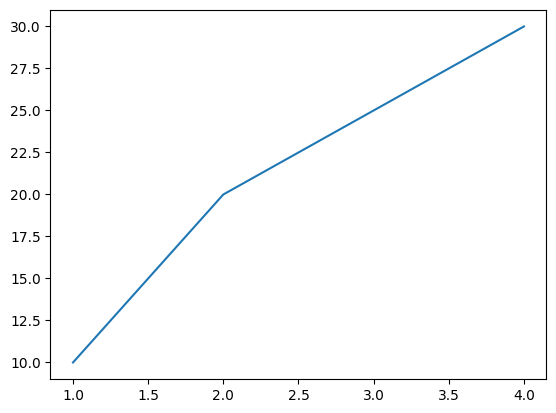

In [42]:
## Create an empty figure with one axes:

fig, ax = plt.subplots()

#Add a simple line plot:
ax.plot([1,2,3,4], [10,20,25,30])

#Show the figure:
plt.show()

### Simple Line Plot

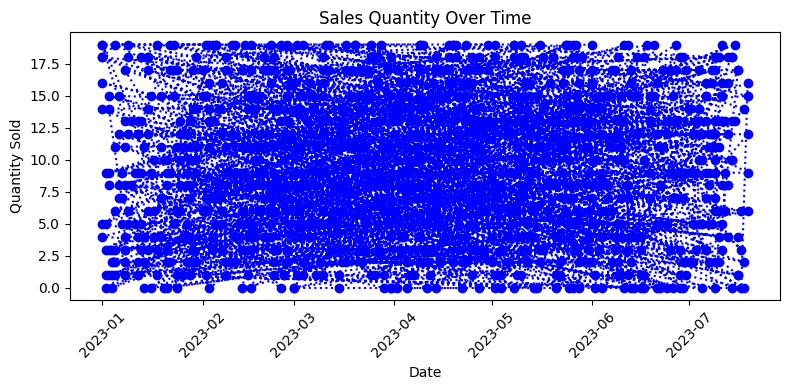

In [43]:
fig, ax = plt.subplots(figsize = (8, 4))

ax.plot(df_csv['Date'], df_csv['Quantity'], marker = 'o', linestyle = ':', color = 'blue')

## Add labels and title:
ax.set_title("Sales Quantity Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Quantity Sold")

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [44]:
df_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1000 non-null   datetime64[ns]
 1   Product   1000 non-null   int32         
 2   Category  950 non-null    category      
 3   Quantity  1000 non-null   int32         
 4   Price     1000 non-null   int32         
 5   Discount  1000 non-null   object        
dtypes: category(1), datetime64[ns](1), int32(3), object(1)
memory usage: 28.7+ KB


In [45]:
df_csv.sort_values('Date', inplace = True)

#### Aggregate by Date

In [46]:
daily_sales = df_csv.groupby('Date')['Quantity'].sum().reset_index()

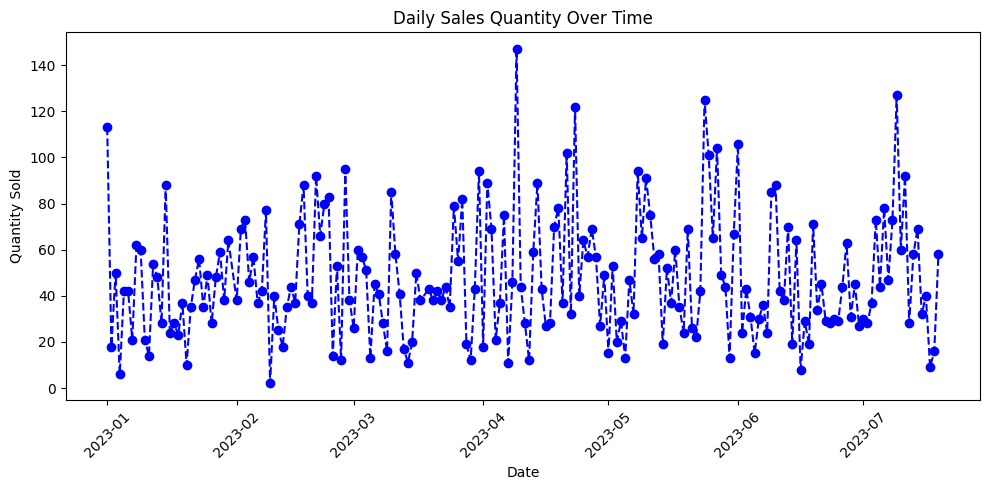

In [47]:
fig, ax = plt.subplots(figsize = (10, 5))

ax.plot(daily_sales['Date'], daily_sales['Quantity'], marker = 'o', linestyle = '--', color = 'blue')

ax.set_title("Daily Sales Quantity Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Quantity Sold")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

### Resample for weekly/ Monthly Trends

C:\Users\sarve\AppData\Local\Temp\ipykernel_14532\1836213961.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df_csv.resample('M', on = 'Date')['Quantity'].sum()


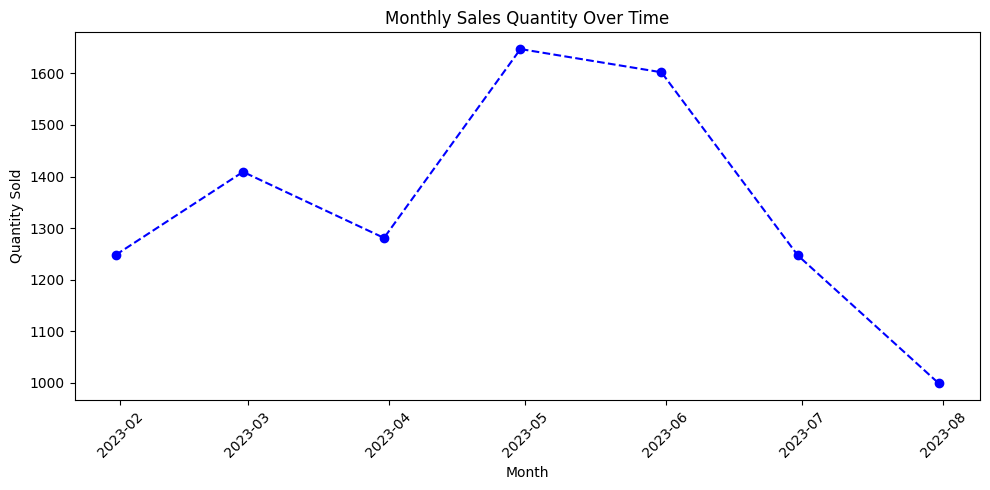

In [48]:
monthly_sales = df_csv.resample('M', on = 'Date')['Quantity'].sum()

fig, ax = plt.subplots(figsize = (10, 5))
ax.plot(monthly_sales.index, monthly_sales.values, marker = 'o',  linestyle = '--', color = 'blue')
ax.set_title("Monthly Sales Quantity Over Time")
ax.set_xlabel("Month")
ax.set_ylabel("Quantity Sold")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

### Barchart

In [49]:
import warnings
warnings.filterwarnings('ignore')

In [50]:
category_sales = df_csv.groupby("Category")['Quantity'].sum().sort_values()

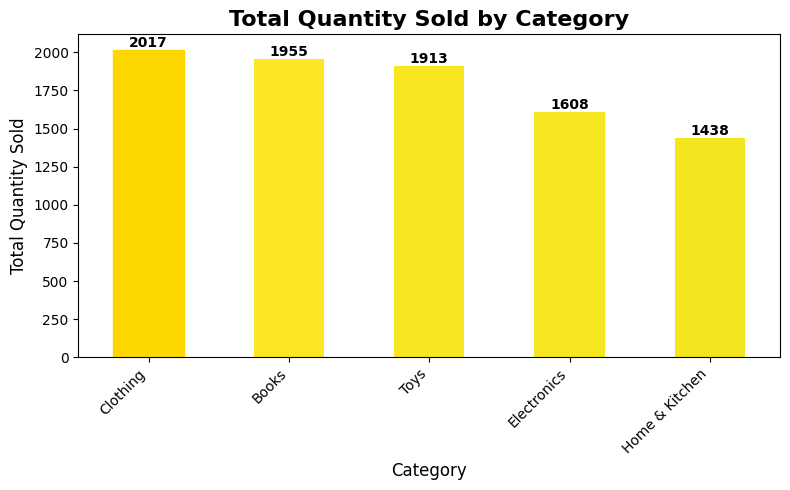

In [51]:
# Load the dataset from a CSV file

import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("sales_data.csv")

# Group data by Category and sum Quantity
category_sales = (
    df.groupby("Category")["Quantity"]
    .sum()
    .sort_values(ascending=False)  # Sort highest to lowest
)

# Create figure & axis
fig, ax = plt.subplots(figsize=(8, 5))

# Plot with custom color palette
bars = category_sales.plot(
    kind="bar",
    color=plt.cm.viridis_r(range(len(category_sales))),
    ax=ax
)

# Add title and labels
ax.set_title("Total Quantity Sold by Category", fontsize=16, fontweight="bold")
ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("Total Quantity Sold", fontsize=12)

# Rotate x-axis labels for clarity
plt.xticks(rotation=45, ha="right")

# Add value labels above bars
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.0f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

# Highlight the top category
top_bar = ax.patches[0]
top_bar.set_color("gold")

# Clean layout
plt.tight_layout()
plt.show()


## Histogram

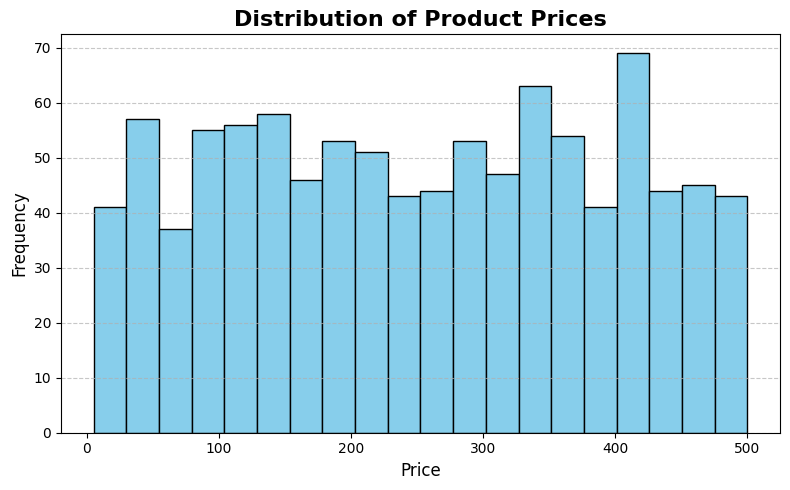

In [52]:
fig, ax = plt.subplots(figsize = (8, 5))

#Plot histogram for price:

ax.hist(
    df_csv['Price'].dropna(),
    bins = 20,
    color = "skyblue",
    edgecolor = "black"
)

# Titles & Labels:
ax.set_title("Distribution of Product Prices", fontsize = 16, fontweight = "bold")
ax.set_xlabel("Price", fontsize = 12)
ax.set_ylabel("Frequency", fontsize = 12)

#Add grid for better readability
ax.grid(axis = "y", linestyle = "--", alpha = 0.7)

#Show plot:
plt.tight_layout()
plt.show()

## Boxplot

In [53]:
import matplotlib.pyplot as plt
import pandas

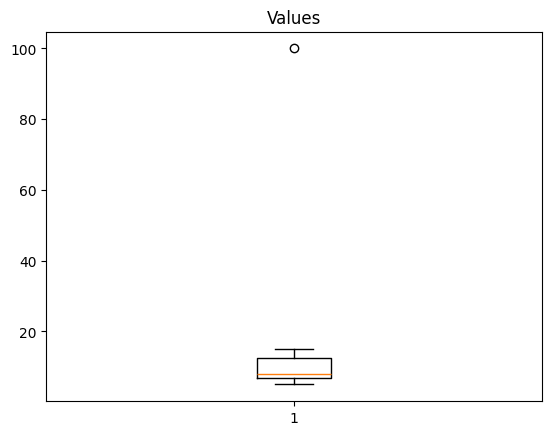

In [54]:
#sample data:
data = [7,8, 5, 6, 12, 15, 14, 10, 6, 8, 7, 100] # Includes the outliers as well

plt.boxplot(data)
plt.title("Values")
plt.show()

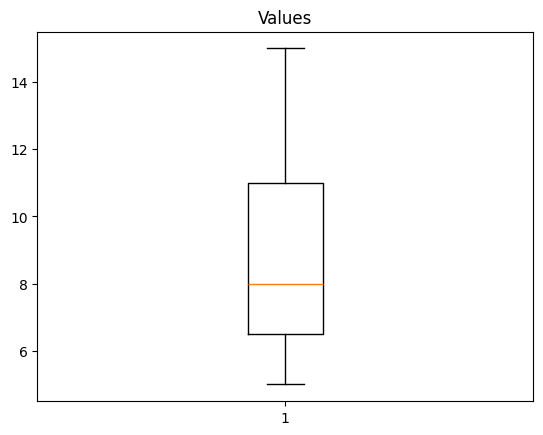

In [55]:
#sample data:
data = [7,8, 5, 6, 12, 15, 14, 10, 6, 8, 7] # Includes the outliers as well

plt.boxplot(data)
plt.title("Values")
plt.show()

### Customized boxplot

In [56]:
df_csv

,Date,Product,Category,Quantity,Price,Discount
825,2023-01-01,60,Books,5,378,11%
709,2023-01-01,61,Clothing,4,113,4%
741,2023-01-01,11,Books,14,20,12%
950,2023-01-01,53,Home & Kitchen,19,131,10%
137,2023-01-01,40,Books,18,107,28%
...,...,...,...,...,...,...
704,2023-07-19,87,Home & Kitchen,9,423,26%
751,2023-07-19,18,Home & Kitchen,6,278,25%
302,2023-07-19,85,Home & Kitchen,15,63,25%
190,2023-07-19,100,Clothing,16,220,5%


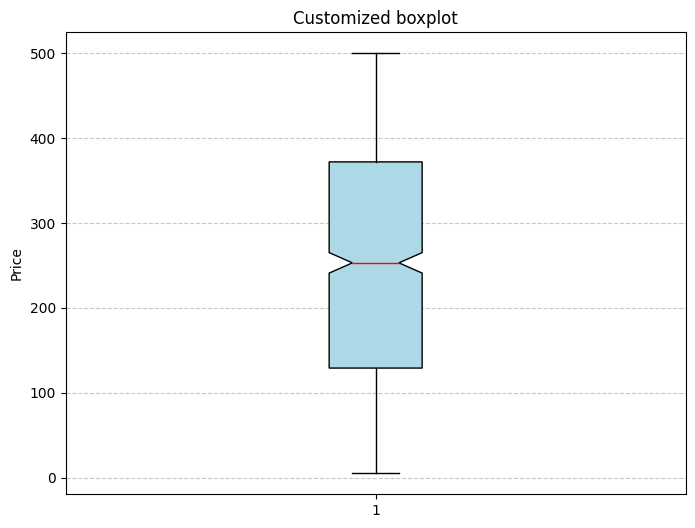

In [57]:
plt.figure(figsize = (8, 6))

plt.boxplot(df_csv['Price'], 
            patch_artist= True, 
            notch = True,
           boxprops = dict(facecolor='lightblue', color = 'black'),
           medianprops = dict(color = 'red'),
           whiskerprops = dict(color='black'),
           capprops = dict(color='black'),
           flierprops=dict(markerfacecolor='orange', marker='o', markersize = 6))

plt.title("Customized boxplot")
plt.ylabel("Price")
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.show()

In [58]:
# Display the first 5 rows to inspect the data

df_csv.head()

,Date,Product,Category,Quantity,Price,Discount
825,2023-01-01,60,Books,5,378,11%
709,2023-01-01,61,Clothing,4,113,4%
741,2023-01-01,11,Books,14,20,12%
950,2023-01-01,53,Home & Kitchen,19,131,10%
137,2023-01-01,40,Books,18,107,28%


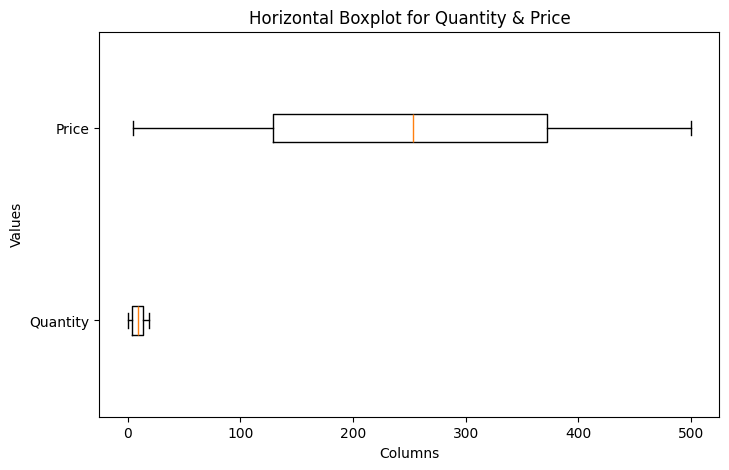

In [59]:
plt.figure(figsize = (8, 5))

plt.boxplot([df_csv['Quantity'], df_csv['Price']], vert = False, labels = ["Quantity", "Price"])

#Title & Labels

plt.title("Horizontal Boxplot for Quantity & Price")
plt.ylabel("Values")
plt.xlabel("Columns")

plt.show()

## Scatter plot with random data

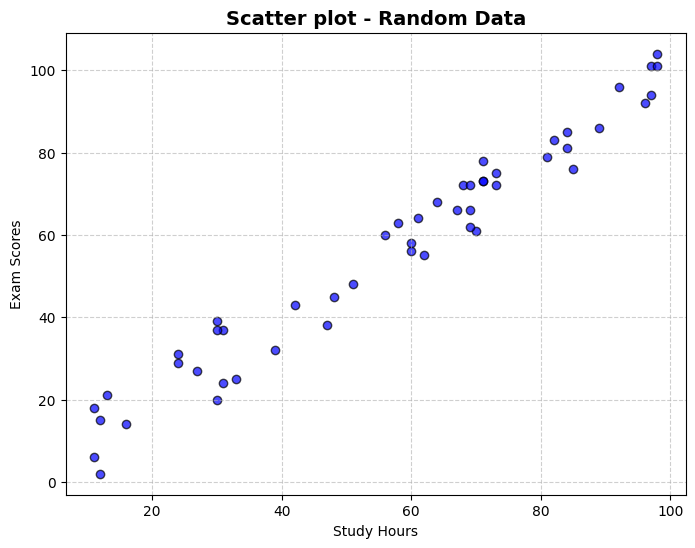

In [60]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Step1: Create random data:
np.random.seed(42) #for reproducibility
x = np.random.randint(10, 100, 50) #eg., study hours
y = x + np.random.randint(-10, 10, 50) # eg., Exam scores with some variations

#Step2: Plot scatter plot:
plt.figure(figsize = (8, 6))
plt.scatter(x, y, color = 'blue', alpha = 0.7, edgecolors = 'black')

plt.title("Scatter plot - Random Data", fontsize = 14, fontweight = 'bold')
plt.xlabel("Study Hours")
plt.ylabel("Exam Scores")
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.show()

## Scatter plot for Quantity sold vs. Price

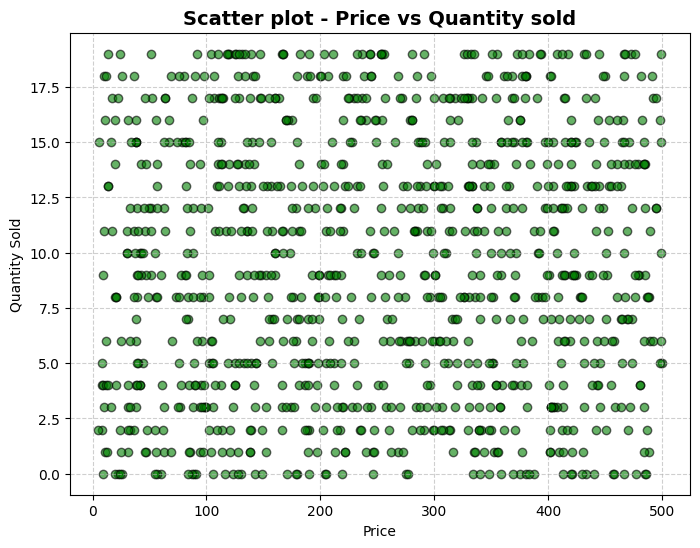

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize = (8, 6))
plt.scatter(df_csv['Price'], df_csv['Quantity'],
           color = 'green', alpha = 0.6, edgecolors = 'black')

plt.title("Scatter plot - Price vs Quantity sold", fontsize = 14, fontweight = 'bold')
plt.xlabel("Price")
plt.ylabel("Quantity Sold")
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.show()

In [62]:
df_excel.head()

,Name,Subject,Score,Hours_Studied
0,Student_51,History,11.0,9.8
1,Student_141,History,20.0,9.3
2,Student_168,Science,10.0,7.3
3,Student_109,Science,43.0,9.6
4,Student_207,Science,57.0,12.0


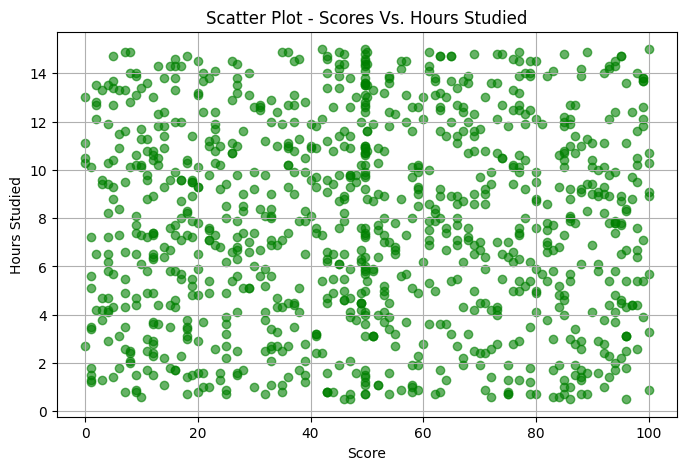

In [63]:
plt.figure(figsize = (8, 5))

plt.scatter(df_excel['Score'], df_excel['Hours_Studied'], alpha = 0.6, c = 'green')
plt.xlabel("Score")
plt.ylabel("Hours Studied")
plt.title("Scatter Plot - Scores Vs. Hours Studied")
plt.grid(True)
plt.show()

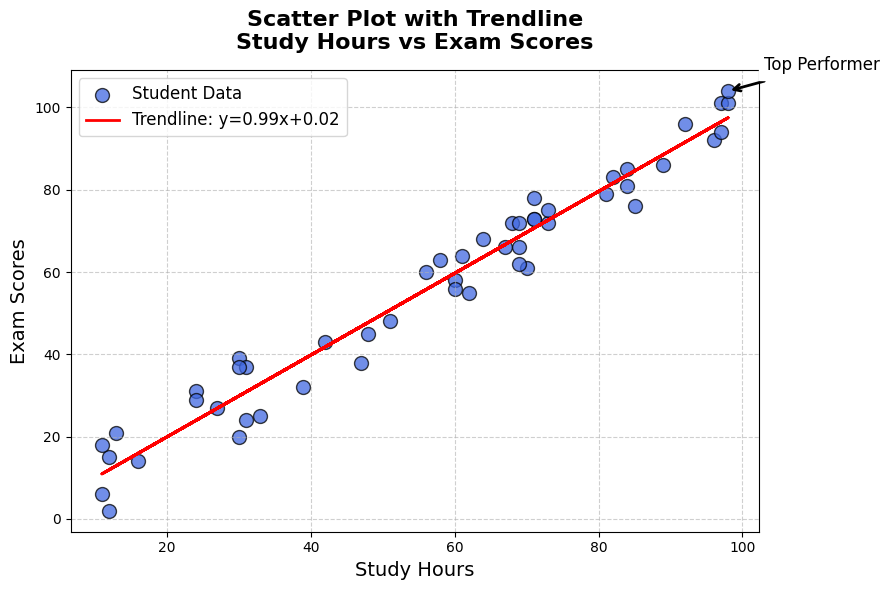

In [64]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Step 1: Create reproducible random data
np.random.seed(42)  # ensures results are the same every run
x = np.random.randint(10, 100, 50)  # Example: Study hours
y = x + np.random.randint(-10, 10, 50)  # Exam scores with variation

# Step 2: Plot scatter plot with enhancements
plt.figure(figsize=(9, 6))
plt.scatter(
    x, y, 
    color='royalblue', 
    alpha=0.75, 
    edgecolors='black', 
    s=100,             # Marker size
    marker='o',        # Circle markers
    label='Student Data'
)

# Step 3: Add a trendline (to show correlation visually)
z = np.polyfit(x, y, 1)   # Linear fit
p = np.poly1d(z)
plt.plot(x, p(x), color='red', linewidth=2, label=f'Trendline: y={z[0]:.2f}x+{z[1]:.2f}')

# Step 4: Add titles, labels, grid, and legend
plt.title("Scatter Plot with Trendline\nStudy Hours vs Exam Scores", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Study Hours", fontsize=14)
plt.ylabel("Exam Scores", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True, fontsize=12)

# Step 5: Annotate one interesting data point (for teaching)
max_score_index = np.argmax(y)
plt.annotate(
    "Top Performer", 
    xy=(x[max_score_index], y[max_score_index]), 
    xytext=(x[max_score_index]+5, y[max_score_index]+5),
    arrowprops=dict(facecolor='green', arrowstyle='->', linewidth=2),
    fontsize=12,
    backgroundcolor='white'
)

# Step 6: Show the plot
plt.tight_layout()
plt.show()


## Line chart

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

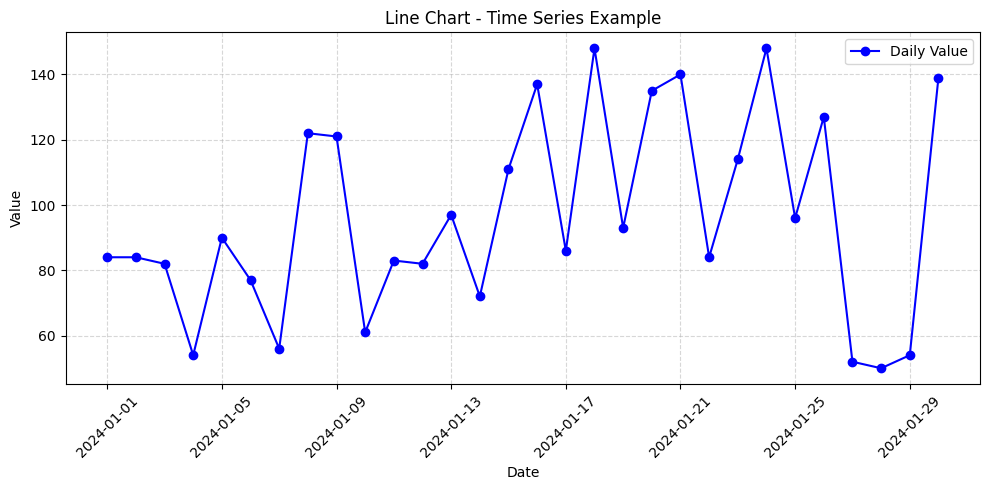

In [66]:
# Create sample time series data

dates = pd.date_range(start = '2024-01-01', periods = 30, freq = 'D')
values = np.random.randint(50, 150, size = 30)

df = pd.DataFrame({
    "Date": dates,
    "Value": values
})

plt.figure(figsize = (10, 5))
plt.plot(df['Date'], df['Value'], marker = 'o', linestyle = '-', color = 'blue', label = "Daily Value")

#Formating:
plt.title("Line Chart - Time Series Example")
plt.xlabel("Date")
plt.ylabel("Value")
plt.xticks(rotation = 45)
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.legend()
plt.tight_layout()
plt.show()

### Two linecharts

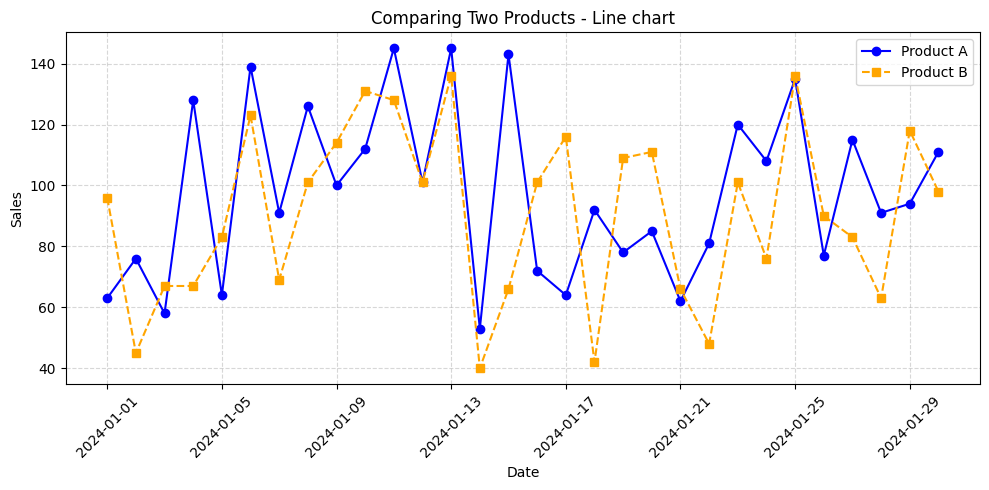

In [67]:
# Creating two sample time series data:
dates = pd.date_range(start = '2024-01-01', periods = 30, freq = 'D')

product_a = np.random.randint(50, 150, size = 30)
product_b = np.random.randint(40, 140, size = 30)

df = pd.DataFrame({
    "Date": dates,
    "ProductA": product_a,
    "ProductB": product_b
})

# Plot linecharts for two products:
plt.figure(figsize = (10, 5))
plt.plot(df['Date'], df['ProductA'], marker = 'o', linestyle = '-', color = 'blue', label = "Product A")
plt.plot(df['Date'], df['ProductB'], marker = 's', linestyle = '--', color = 'orange', label = "Product B")

#Formating:
plt.title("Comparing Two Products - Line chart")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation = 45)
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
df_excel.head()

,Name,Subject,Score,Hours_Studied
0,Student_51,History,11.0,9.8
1,Student_141,History,20.0,9.3
2,Student_168,Science,10.0,7.3
3,Student_109,Science,43.0,9.6
4,Student_207,Science,57.0,12.0


In [69]:
# Display the first 5 rows to inspect the data

df_csv.head()

,Date,Product,Category,Quantity,Price,Discount
825,2023-01-01,60,Books,5,378,11%
709,2023-01-01,61,Clothing,4,113,4%
741,2023-01-01,11,Books,14,20,12%
950,2023-01-01,53,Home & Kitchen,19,131,10%
137,2023-01-01,40,Books,18,107,28%


In [70]:
df_csv['Discount'] = df_csv['Discount'].str.replace('%', "").astype(float)

In [71]:
# Display the first 5 rows to inspect the data

df_csv.head()

,Date,Product,Category,Quantity,Price,Discount
825,2023-01-01,60,Books,5,378,11.0
709,2023-01-01,61,Clothing,4,113,4.0
741,2023-01-01,11,Books,14,20,12.0
950,2023-01-01,53,Home & Kitchen,19,131,10.0
137,2023-01-01,40,Books,18,107,28.0


In [72]:
## Summary statistics for numerical column:

df_csv.describe()

,Date,Product,Quantity,Price,Discount
count,1000,1000.000000,1000.0000,1000.000000,1000.000000
mean,2023-04-11 16:43:40.800000,52.624000,9.4330,251.960000,14.580000
min,2023-01-01 00:00:00,1.000000,0.0000,5.000000,0.000000
25%,2023-02-20 18:00:00,26.000000,4.0000,129.000000,7.000000
50%,2023-04-14 00:00:00,52.500000,9.0000,253.000000,14.000000
75%,2023-05-30 06:00:00,80.000000,14.0000,372.000000,22.000000
max,2023-07-19 00:00:00,100.000000,19.0000,500.000000,30.000000
std,NaN,30.272745,5.7842,141.046129,8.627632


In [73]:
df_csv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 825 to 88
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1000 non-null   datetime64[ns]
 1   Product   1000 non-null   int32         
 2   Category  950 non-null    category      
 3   Quantity  1000 non-null   int32         
 4   Price     1000 non-null   int32         
 5   Discount  1000 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(1), int32(3)
memory usage: 36.3 KB


In [74]:
df_excel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Name           1000 non-null   object 
 1   Subject        1000 non-null   object 
 2   Score          1000 non-null   float64
 3   Hours_Studied  1000 non-null   float64
dtypes: float64(2), object(2)
memory usage: 31.4+ KB


In [75]:
# Summary statistics for categorical column:

df_excel.describe(include = ['object', 'bool'])

,Name,Subject
count,1000,1000
unique,289,5
top,Student_257,Art
freq,10,222


df_excel.describe(include = ['all'])

In [76]:
df_csv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 825 to 88
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1000 non-null   datetime64[ns]
 1   Product   1000 non-null   int32         
 2   Category  950 non-null    category      
 3   Quantity  1000 non-null   int32         
 4   Price     1000 non-null   int32         
 5   Discount  1000 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(1), int32(3)
memory usage: 36.3 KB


In [77]:
##Additional Insights:

df_csv['Category'].nunique()

5

In [78]:
df_csv['Category'].value_counts()

Category
Books             212
Clothing          205
Toys              192
Electronics       185
Home & Kitchen    156
Name: count, dtype: int64

In [79]:
df_csv['Category'].mode()[0]

'Books'

In [80]:
# Display the first 5 rows to inspect the data

df_csv.head()

,Date,Product,Category,Quantity,Price,Discount
825,2023-01-01,60,Books,5,378,11.0
709,2023-01-01,61,Clothing,4,113,4.0
741,2023-01-01,11,Books,14,20,12.0
950,2023-01-01,53,Home & Kitchen,19,131,10.0
137,2023-01-01,40,Books,18,107,28.0


In [81]:
df_csv['Price'].mean()

251.96

## groupby()

Split --> Apply --> Combine

1. To **Summarize** large datasets quickly
2. To perform **comparisions** across groups
3. To find **patterns** in categorical variables

In [82]:
df_csv.groupby("Category")['Price'].mean()

Category
Books             241.311321
Clothing          262.009756
Electronics       249.772973
Home & Kitchen    260.942308
Toys              245.953125
Name: Price, dtype: float64

In [83]:
df_csv.groupby('Category').agg({
    "Price": "mean",
    "Quantity": "sum"
})

,Price,Quantity
Category,,
Books,241.311321,1955
Clothing,262.009756,2017
Electronics,249.772973,1608
Home & Kitchen,260.942308,1438
Toys,245.953125,1913


In [84]:
df_csv.groupby('Category').agg({
    "Price": ["mean", "min", "max", "std"],
    "Quantity": ["sum", "mean"]
})

Price                      Quantity          
                      mean min  max         std      sum      mean
Category                                                          
Books           241.311321   6  499  141.240534     1955  9.221698
Clothing        262.009756   5  495  134.186693     2017  9.839024
Electronics     249.772973   9  499  145.857481     1608  8.691892
Home & Kitchen  260.942308   8  484  141.294624     1438  9.217949
Toys            245.953125  11  499  140.062188     1913  9.963542

In [85]:
### Rename columns after aggregation:

df_csv.groupby("Category").agg(
avg_price = ("Price", "mean"),
min_price = ("Price", "min"),
    max_price = ("Price", "max"),
    total_quantity = ("Quantity", "sum")
)

,avg_price,min_price,max_price,total_quantity
Category,,,,
Books,241.311321,6,499,1955
Clothing,262.009756,5,495,2017
Electronics,249.772973,9,499,1608
Home & Kitchen,260.942308,8,484,1438
Toys,245.953125,11,499,1913


In [86]:
df_csv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 825 to 88
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1000 non-null   datetime64[ns]
 1   Product   1000 non-null   int32         
 2   Category  950 non-null    category      
 3   Quantity  1000 non-null   int32         
 4   Price     1000 non-null   int32         
 5   Discount  1000 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(1), int32(3)
memory usage: 36.3 KB


df_csv.groupby(["Category", "Region"]).agg(
avg_price = ("Price", "mean"),
total_quantity = ("Quantity", "sum")
)

## Syntax of Pivot Table

pd.pivot_table(
    data,                    #### DataFrame
    values = None,          ##### The columns to aggregatre
    index = None,           ### Rows
    columns = None,         ## Columns
    aggfunc = 'mean',       ## Aggregation Function
    fill_value = None       ### Replace NaN values
)

## What is the total sales amount per Category per Date?
Sales = Quantity * Price

In [87]:
# Display the first 5 rows to inspect the data

df_csv.head()

,Date,Product,Category,Quantity,Price,Discount
825,2023-01-01,60,Books,5,378,11.0
709,2023-01-01,61,Clothing,4,113,4.0
741,2023-01-01,11,Books,14,20,12.0
950,2023-01-01,53,Home & Kitchen,19,131,10.0
137,2023-01-01,40,Books,18,107,28.0


In [88]:
df_csv['Sales'] = df_csv['Quantity'] * df_csv['Price']

In [89]:
# Display the first 5 rows to inspect the data

df_csv.head()

,Date,Product,Category,Quantity,Price,Discount,Sales
825,2023-01-01,60,Books,5,378,11.0,1890
709,2023-01-01,61,Clothing,4,113,4.0,452
741,2023-01-01,11,Books,14,20,12.0,280
950,2023-01-01,53,Home & Kitchen,19,131,10.0,2489
137,2023-01-01,40,Books,18,107,28.0,1926


In [90]:
pivot = pd.pivot_table(
df_csv,
values = "Sales",
index = "Date",
columns = "Category",
aggfunc = "sum",
fill_value = 0
)

In [91]:
pivot

Category,Books,Clothing,Electronics,Home & Kitchen,Toys
Date,,,,,
2023-01-01,4592,452,4824,5662,0
2023-01-02,264,3928,0,0,31
2023-01-03,7938,5094,383,0,0
2023-01-04,678,0,282,410,0
2023-01-05,0,2519,0,138,5845
...,...,...,...,...,...
2023-07-15,0,0,0,0,2090
2023-07-16,0,4080,8415,121,812
2023-07-17,0,0,1344,0,882


In [92]:
# Display the first 5 rows to inspect the data

df_csv.head()

,Date,Product,Category,Quantity,Price,Discount,Sales
825,2023-01-01,60,Books,5,378,11.0,1890
709,2023-01-01,61,Clothing,4,113,4.0,452
741,2023-01-01,11,Books,14,20,12.0,280
950,2023-01-01,53,Home & Kitchen,19,131,10.0,2489
137,2023-01-01,40,Books,18,107,28.0,1926


In [93]:
np.random.seed(42) 
regions = ['North', 'South', 'East', 'West']

df_csv['Region'] = np.random.choice(regions, len(df_csv))

In [94]:
## Extract month name from Date:

df_csv['Month'] = df_csv['Date'].dt.strftime('%b')

In [95]:
# Display the first 5 rows to inspect the data

df_csv.head()

,Date,Product,Category,Quantity,Price,Discount,Sales,Region,Month
825,2023-01-01,60,Books,5,378,11.0,1890,East,Jan
709,2023-01-01,61,Clothing,4,113,4.0,452,West,Jan
741,2023-01-01,11,Books,14,20,12.0,280,North,Jan
950,2023-01-01,53,Home & Kitchen,19,131,10.0,2489,East,Jan
137,2023-01-01,40,Books,18,107,28.0,1926,East,Jan


In [96]:
pivot = pd.pivot_table(
df_csv,
    index = ["Region", "Category"],
    columns = "Month",
    values = ["Sales", "Quantity", "Discount"],
    aggfunc = {"Sales": "sum", "Quantity":"sum", "Discount": 'mean'},
    fill_value = 0
)

In [97]:
import seaborn as sns

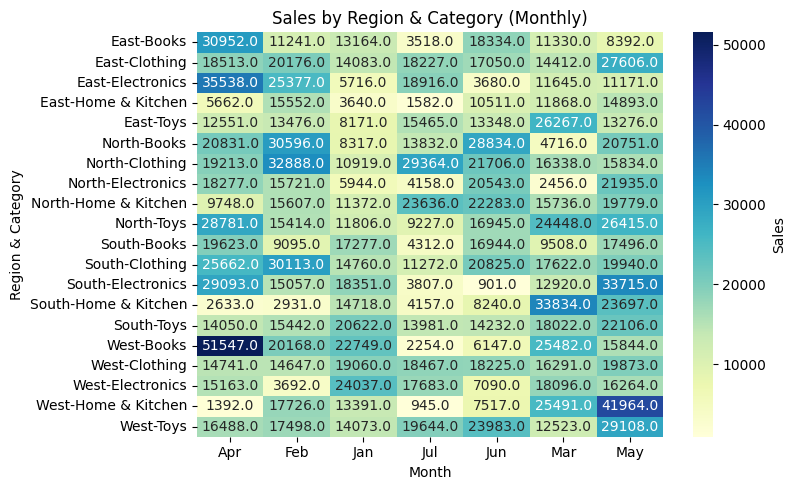

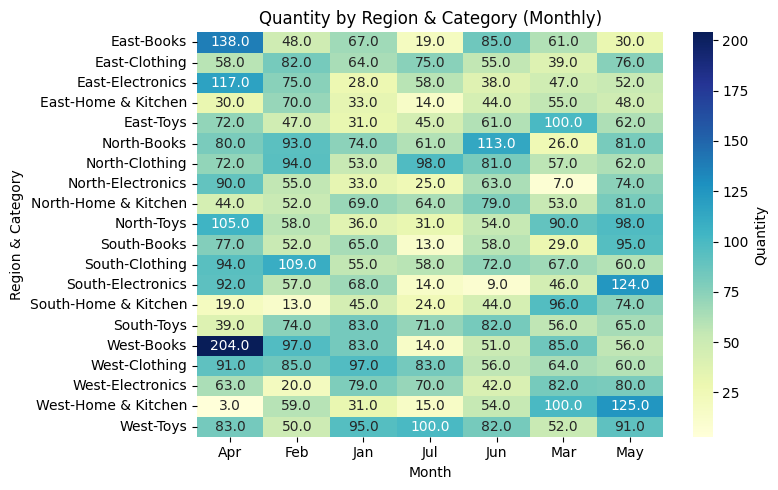

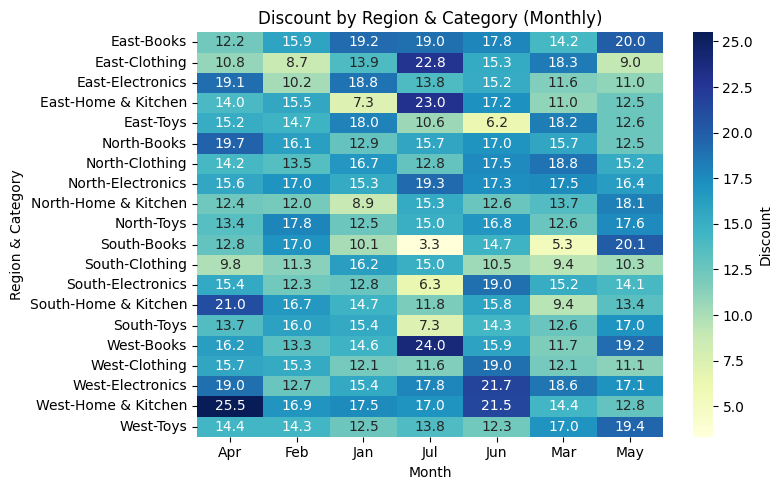

In [98]:
# Loop through each metric in the pivot table and plot a heatmap

for metric in ["Sales", "Quantity", "Discount"]:
    plt.figure(figsize=(8, 5))
    sns.heatmap(
        pivot[metric], 
        annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': metric}
    )
    plt.title(f"{metric} by Region & Category (Monthly)")
    plt.ylabel("Region & Category")
    plt.xlabel("Month")
    plt.tight_layout()
    plt.show()

In [99]:
df_excel

,Name,Subject,Score,Hours_Studied
0,Student_51,History,11.0,9.8
1,Student_141,History,20.0,9.3
2,Student_168,Science,10.0,7.3
3,Student_109,Science,43.0,9.6
4,Student_207,Science,57.0,12.0
...,...,...,...,...
995,Student_223,Science,100.0,15.0
996,Student_80,Art,61.0,7.1
997,Student_234,Math,47.0,11.4
998,Student_184,History,9.0,10.2


## Correlation Analysis

In [100]:
# Load the dataset from a CSV file

df = pd.read_csv("correlation_demo.csv")

df.head()

,Advertising_Spend,Sales,Website_Traffic,Customer_Satisfaction,Product_Quality,Return_Rate,Discount_Offered,Employee_Productivity,Social_Media_Engagement,Market_Share
0,100,20,1500,7.5,8.0,5.0,10,80,300,5
1,200,45,2500,8.0,8.2,4.8,12,82,450,8
2,300,50,3000,7.8,8.1,4.7,15,83,500,9
3,400,80,4000,8.2,8.4,4.5,18,85,650,12
4,500,100,4800,8.5,8.5,4.4,20,87,800,15


In [101]:
print("\nInterpretation Guide:")
print("""
+1 → Perfect positive relationship
-1 → Perfect negative relationship
0  → No relationship

Look for values close to +1 or -1 to find strong correlations.
""")


Interpretation Guide:

+1 → Perfect positive relationship
-1 → Perfect negative relationship
0  → No relationship

Look for values close to +1 or -1 to find strong correlations.



In [102]:
corr_matrix = df.corr()
print("\nCorrelation Matrix:\n", corr_matrix)


Correlation Matrix:
                          Advertising_Spend     Sales  Website_Traffic  \
Advertising_Spend                 1.000000  0.997289         0.992757   
Sales                             0.997289  1.000000         0.991784   
Website_Traffic                   0.992757  0.991784         1.000000   
Customer_Satisfaction             0.980277  0.987075         0.989573   
Product_Quality                   0.988554  0.995930         0.982533   
Return_Rate                      -0.996021 -0.994007        -0.996264   
Discount_Offered                  0.996172  0.991370         0.982964   
Employee_Productivity             0.998278  0.996186         0.992052   
Social_Media_Engagement           0.997472  0.998287         0.985857   
Market_Share                      0.996945  0.998670         0.996446   

                         Customer_Satisfaction  Product_Quality  Return_Rate  \
Advertising_Spend                     0.980277         0.988554    -0.996021   
Sales         

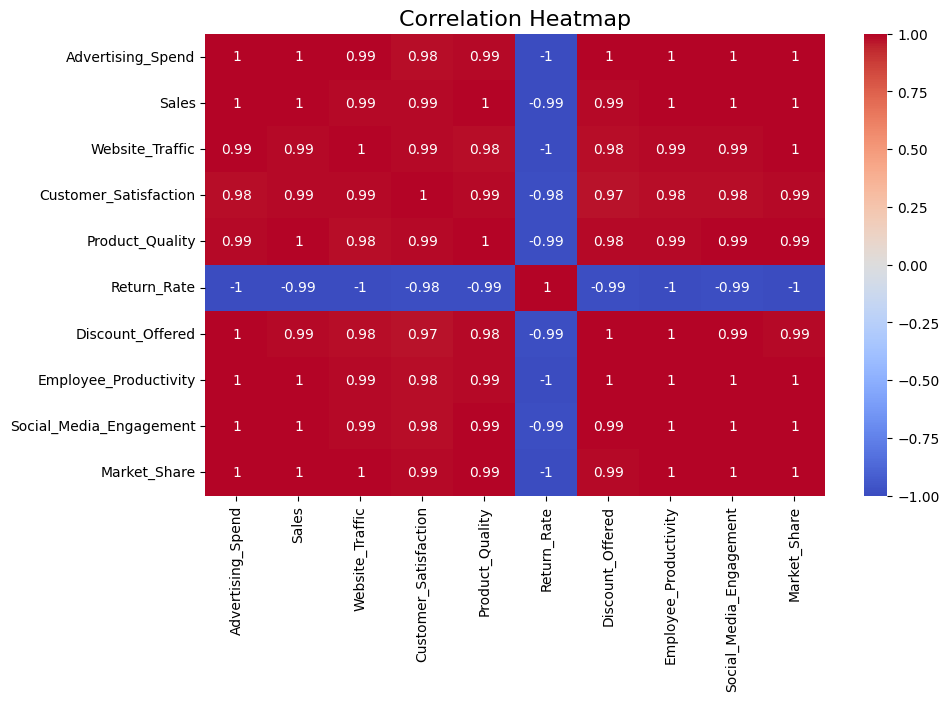

In [103]:
# plot Heatmap:

plt.figure(figsize = (10, 6))
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", vmin = -1, vmax = +1)
plt.title("Correlation Heatmap", fontsize = 16)
plt.show()

In [104]:
df_excel.head()

,Name,Subject,Score,Hours_Studied
0,Student_51,History,11.0,9.8
1,Student_141,History,20.0,9.3
2,Student_168,Science,10.0,7.3
3,Student_109,Science,43.0,9.6
4,Student_207,Science,57.0,12.0


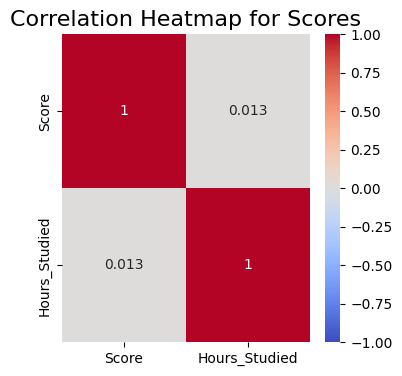

In [105]:
corr_matrix_score = df_excel[['Score', 'Hours_Studied']].corr()

# plot the Heatmap:
plt.figure(figsize = (4, 4))
sns.heatmap(corr_matrix_score, annot = True, cmap = "coolwarm", vmin = -1, vmax = +1)
plt.title("Correlation Heatmap for Scores", fontsize = 16)
plt.show()

## Strength of Correlation

Strength of relationship:
- 0.0 to 0.3 → Weak
- 0.3 to 0.7 → Moderate
- 0.7 to 1.0 → Strong
(Same applies for negative values, just in reverse direction)

## Pearson, Spearman, Kendall

- **Pearson** – For linear relationships, works best when data is normally distributed.
- **Spearman** – Based on ranks, useful for non-linear monotonic trends.
- **Kendall Tau** – Based on concordant/discordant pairs, works well for ordinal data and small datasets.

## Limitations

**Correlation is NOT causation**

In [106]:
# Create sample dataset
np.random.seed(42)
data = pd.DataFrame({
    'Advertising_Spend': np.random.randint(1000, 5000, 1000),
    'Sales_Revenue': np.random.randint(20000, 60000, 100),
    'Customer_Satisfaction': np.random.randint(1, 10, 100),
    'Website_Traffic': np.random.randint(500, 2000, 10),
    'Email_Campaign_Clicks': np.random.randint(100, 500, 10),
    'Product_Ratings': np.random.randint(1, 5, 10),
    'Discount_Offered': np.random.randint(5, 25, 10),
    'Customer_Retention': np.random.randint(50, 100, 10),
    'Support_Tickets': np.random.randint(10, 100, 10),
    'New_Customers': np.random.randint(5, 50, 10)
})

In [109]:
data.shape

(10, 10)

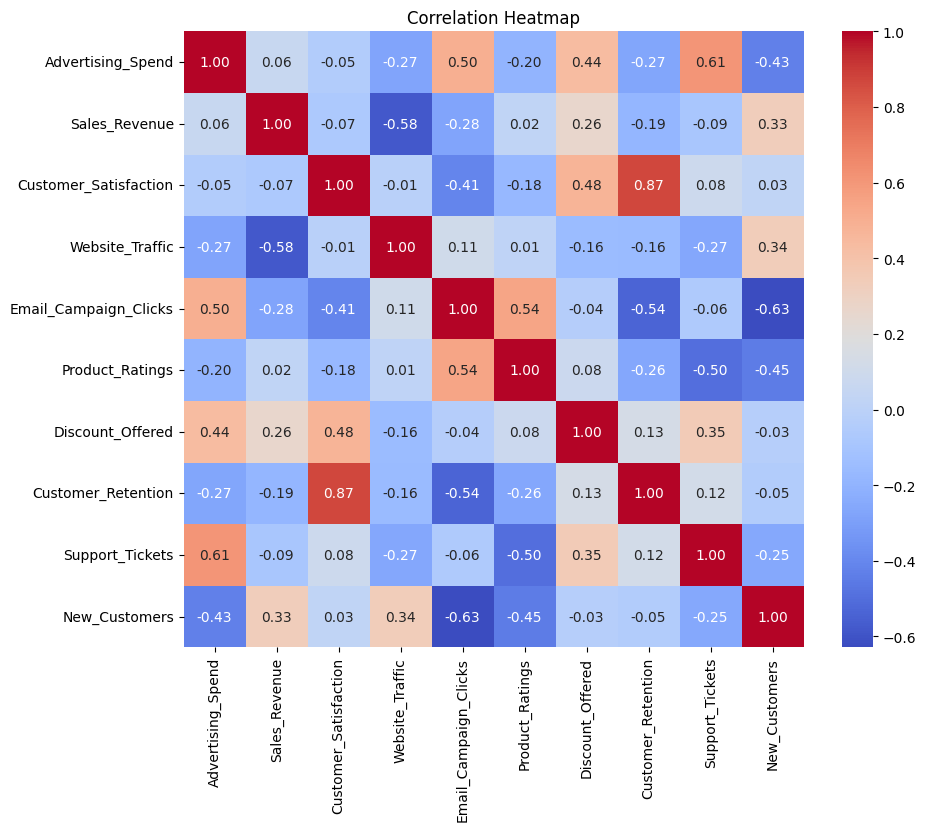

In [108]:
corr_matrix = data.corr(method = "pearson")

#Display correlation heatmap:
plt.figure(figsize = (10, 8))
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Correlation Heatmap")
plt.show()

### Data Transformation

In [110]:
import pandas as pd
import numpy as np

# reproducibility:
np.random.seed(42)


data = pd.DataFrame({
    'Advertising_Spend': np.random.randint(1000, 50000, 1000),         # in ₹
    'Sales_Revenue': np.random.randint(200000, 1000000, 1000),         # in ₹
    'Customer_Satisfaction': np.random.randint(1, 11, 1000),           # 1–10 scale
    'Website_Traffic': np.random.randint(500, 20000, 1000),            # daily visitors
    'Email_Campaign_Clicks': np.random.randint(100, 5000, 1000),       # clicks
    'Product_Ratings': np.random.randint(1, 6, 1000),                  # 1–5 stars
    'Discount_Offered': np.random.randint(5, 50, 1000),                # percentage
    'Customer_Retention': np.random.randint(50, 101, 1000),            # %
    'Support_Tickets': np.random.randint(10, 500, 1000),               # tickets per month
    'New_Customers': np.random.randint(5, 500, 1000)                   # new customers acquired
})

In [111]:
data.head()

,Advertising_Spend,Sales_Revenue,Customer_Satisfaction,Website_Traffic,Email_Campaign_Clicks,Product_Ratings,Discount_Offered,Customer_Retention,Support_Tickets,New_Customers
0,16795,358518,8,7633,4260,4,23,77,365,277
1,1860,324040,4,11705,4020,3,26,65,148,319
2,39158,868406,5,6406,1597,3,23,95,323,398
3,45732,723138,4,3091,3954,4,20,72,183,359
4,12284,618034,4,15649,3271,4,28,69,38,344


X' = (X - Xmin) / (Xmax - Xmin)

X = Original Value
Xmin = minimum value of the column
Xmax = maximum value of the column
X' = scaled(normalized) value

[0, 1]
Smallest value becomes 0 and largest value becomes 1.

### Fit - Scaler learns the minimum and the maximum values of each column in data
### Tranform - Each value in data is then scaled into the range [0, 1] using the formula.

In [112]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler:
scaler = MinMaxScaler()

# Fit and transform the data:
normalized_data = scaler.fit_transform(data)

# Convert back to dataframe for redability:
normalized_df = pd.DataFrame(normalized_data, columns = data.columns)


In [115]:
data.head()

,Advertising_Spend,Sales_Revenue,Customer_Satisfaction,Website_Traffic,Email_Campaign_Clicks,Product_Ratings,Discount_Offered,Customer_Retention,Support_Tickets,New_Customers
0,16795,358518,8,7633,4260,4,23,77,365,277
1,1860,324040,4,11705,4020,3,26,65,148,319
2,39158,868406,5,6406,1597,3,23,95,323,398
3,45732,723138,4,3091,3954,4,20,72,183,359
4,12284,618034,4,15649,3271,4,28,69,38,344


In [114]:
normalized_df.head()

,Advertising_Spend,Sales_Revenue,Customer_Satisfaction,Website_Traffic,Email_Campaign_Clicks,Product_Ratings,Discount_Offered,Customer_Retention,Support_Tickets,New_Customers
0,0.322328,0.198104,0.777778,0.365145,0.849438,0.75,0.409091,0.54,0.725971,0.550607
1,0.017376,0.154982,0.333333,0.574298,0.800409,0.50,0.477273,0.30,0.282209,0.635628
2,0.778948,0.835831,0.444444,0.302121,0.305414,0.50,0.409091,0.90,0.640082,0.795547
3,0.913180,0.654141,0.333333,0.131851,0.786925,0.75,0.340909,0.44,0.353783,0.716599
4,0.230219,0.522686,0.333333,0.776876,0.647395,0.75,0.522727,0.38,0.057260,0.686235


### Z-Score Transformation

Z = (X - mu) / sd

X = data point
mu = mean of the feature
sd = standard deviation of the feature

In [116]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the data:
zscore_data = scaler.fit_transform(data)

# Convert back to DataFrame:
zscore_df = pd.DataFrame(zscore_data, columns = data.columns)

In [117]:
zscore_df.head()

,Advertising_Spend,Sales_Revenue,Customer_Satisfaction,Website_Traffic,Email_Campaign_Clicks,Product_Ratings,Discount_Offered,Customer_Retention,Support_Tickets,New_Customers
0,-0.566931,-1.066438,0.882561,-0.467330,1.190877,0.667364,-0.301850,0.162717,0.759912,0.202432
1,-1.608573,-1.214546,-0.529536,0.260283,1.019843,-0.047924,-0.066091,-0.640165,-0.827231,0.501709
2,0.992777,1.123908,-0.176512,-0.686578,-0.706893,-0.047924,-0.301850,1.367041,0.452723,1.064635
3,1.451281,0.499875,-0.529536,-1.278925,0.972808,0.667364,-0.537610,-0.171817,-0.571240,0.786735
4,-0.881551,0.048376,-0.529536,0.965023,0.486073,0.667364,0.091082,-0.372537,-1.631773,0.679850


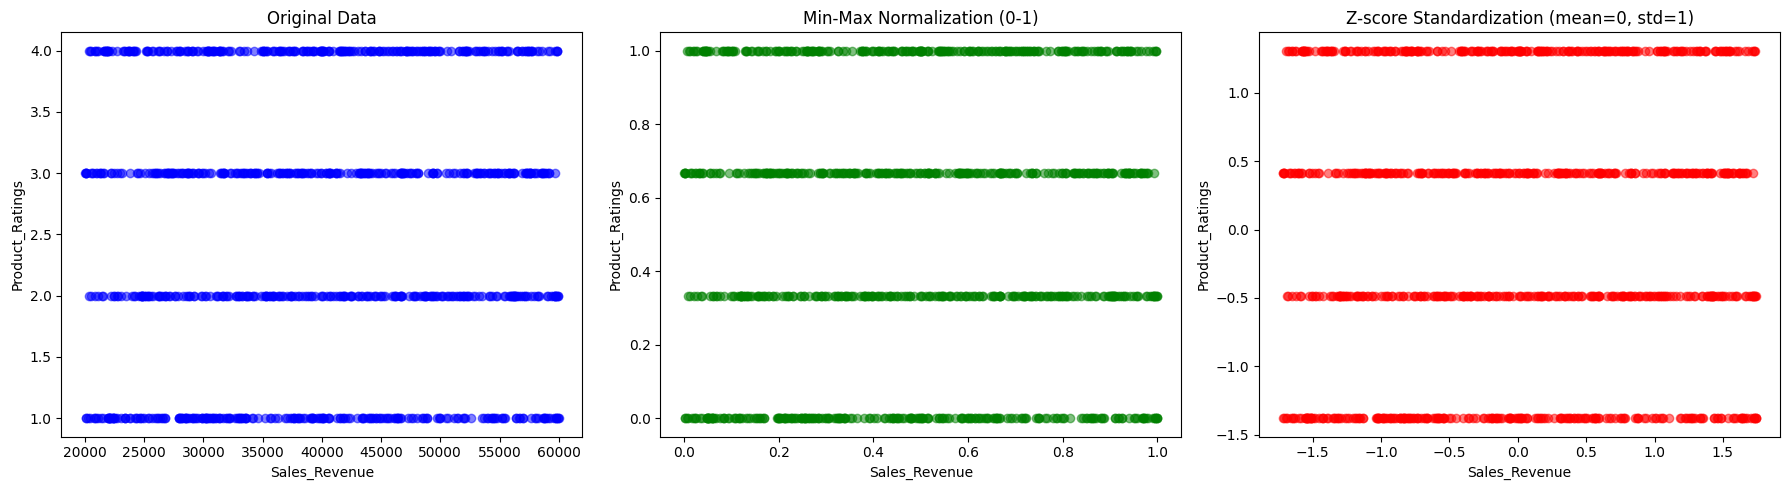

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Generate a larger dataset
np.random.seed(42)
data = pd.DataFrame({
    'Advertising_Spend': np.random.randint(1000, 5000, 1000),
    'Sales_Revenue': np.random.randint(20000, 60000, 1000),
    'Customer_Satisfaction': np.random.randint(1, 10, 1000),
    'Website_Traffic': np.random.randint(500, 2000, 1000),
    'Email_Campaign_Clicks': np.random.randint(100, 500, 1000),
    'Product_Ratings': np.random.randint(1, 5, 1000),
    'Discount_Offered': np.random.randint(5, 25, 1000),
    'Customer_Retention': np.random.randint(50, 100, 1000),
    'Support_Tickets': np.random.randint(10, 100, 1000),
    'New_Customers': np.random.randint(5, 50, 1000)
})

# Select 2 columns for visualization
cols = ['Sales_Revenue', 'Product_Ratings']

# Min-Max Normalization
scaler_minmax = MinMaxScaler()
data_minmax = scaler_minmax.fit_transform(data[cols])

# Z-score Standardization
scaler_std = StandardScaler()
data_std = scaler_std.fit_transform(data[cols])

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original
axes[0].scatter(data[cols[0]], data[cols[1]], alpha=0.5, color="blue")
axes[0].set_title("Original Data")
axes[0].set_xlabel(cols[0])
axes[0].set_ylabel(cols[1])

# Min-Max Normalization
axes[1].scatter(data_minmax[:, 0], data_minmax[:, 1], alpha=0.5, color="green")
axes[1].set_title("Min-Max Normalization (0-1)")
axes[1].set_xlabel(cols[0])
axes[1].set_ylabel(cols[1])

# Z-score Standardization
axes[2].scatter(data_std[:, 0], data_std[:, 1], alpha=0.5, color="red")
axes[2].set_title("Z-score Standardization (mean=0, std=1)")
axes[2].set_xlabel(cols[0])
axes[2].set_ylabel(cols[1])

plt.tight_layout()
plt.show()


## Encoding Categorical Variables

#### Common Types of Encoding:
1. Label Encoding   -> Ordinal Data
2. One-Hot Encoding -> Nominal Data (No Order)
3. Target Encoding  -> If the categories are too many.
4. Frequency Encoding
5. Embedding Encoding

In [120]:
np.random.seed(42)

data = pd.DataFrame({
    'Advertising_Spend': np.random.randint(1000, 5000, 10),
    'Sales_Revenue': np.random.randint(20000, 60000, 10),
    'Customer_Satisfaction': np.random.randint(1, 10, 10),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], 10)  # Categorical column
})

In [121]:
data.head()

,Advertising_Spend,Sales_Revenue,Customer_Satisfaction,Region
0,4174,36850,1,East
1,4507,57194,6,East
2,1860,41962,9,North
3,2294,36023,1,North
4,2130,21685,3,East


#### Label Encoding

In [122]:
from sklearn.preprocessing import LabelEncoder

In [123]:
#Initialize encoder

label_encoder = LabelEncoder()

## Apply label encoding to the Region column
data['Region_LabelEncoded'] = label_encoder.fit_transform(data['Region'])


In [ ]:
East - 0
North - 1
South - 2
West - 3

In [124]:
data.head()

,Advertising_Spend,Sales_Revenue,Customer_Satisfaction,Region,Region_LabelEncoded
0,4174,36850,1,East,0
1,4507,57194,6,East,0
2,1860,41962,9,North,1
3,2294,36023,1,North,1
4,2130,21685,3,East,0


### One-Hot Encoding

In [125]:
# One-hot encode the Region Column
one_hot_encoded = pd.get_dummies(data['Region'], prefix = "Region")



In [127]:
data.head()

,Advertising_Spend,Sales_Revenue,Customer_Satisfaction,Region,Region_LabelEncoded
0,4174,36850,1,East,0
1,4507,57194,6,East,0
2,1860,41962,9,North,1
3,2294,36023,1,North,1
4,2130,21685,3,East,0


In [126]:
one_hot_encoded

,Region_East,Region_North,Region_South,Region_West
0,True,False,False,False
1,True,False,False,False
2,False,True,False,False
3,False,True,False,False
4,True,False,False,False
5,False,False,True,False
6,False,False,False,True
7,False,True,False,False
8,False,False,False,True
9,False,False,True,False


## Model Saving & ML toolkit

In [128]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import joblib

In [129]:
# Sample dataset:
np.random.seed(42)
X = np.random.rand(100, 1) * 10 # Advertising Spend
y = 2.5 * X.flatten() + np.random.randn(100) * 2 # Sales with noise

In [131]:
# Train-test split:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


In [132]:
## Train a simple model:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [135]:
model.coef_

array([2.41972946])

In [136]:
model.intercept_

0.2858266389171362

In [133]:
# Save the model

joblib.dump(model, "linear_model.pkl")

['linear_model.pkl']

In [134]:
# Load back the model:

loaded_model = joblib.load("linear_model.pkl")

print("Predicted:", loaded_model.predict([[5]]))

Predicted: [12.38447395]


### Report model parameters and metrics

In [137]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [138]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("Coef:", model.coef_[0])
print("Intercept:", model.intercept_)
print("Train R²:", r2_score(y_train, y_pred_train))
print("Test  R²:", r2_score(y_test,  y_pred_test))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))

Coef: 2.4197294629921102
Intercept: 0.2858266389171362
Train R²: 0.9360867457000046
Test  R²: 0.9545718935323327
Test MAE: 1.1826851558379554
Test RMSE: 1.617033721005226


### Visualize fit & residuals 

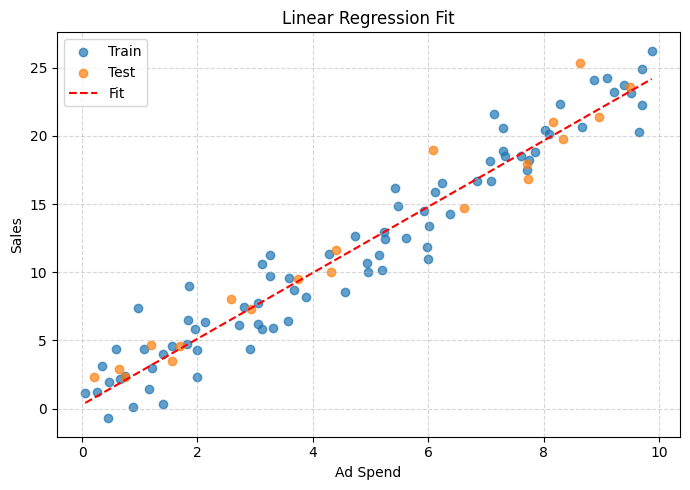

In [139]:
plt.figure(figsize = (7, 5))
plt.scatter(X_train, y_train, alpha = 0.7, label = "Train")
plt.scatter(X_test, y_test, alpha = 0.7, label = "Test")
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
plt.plot(x_line, model.predict(x_line), 'r--', label = "Fit")
plt.xlabel("Ad Spend"); plt.ylabel("Sales");plt.title("Linear Regression Fit")
plt.legend();
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.tight_layout()
plt.show()

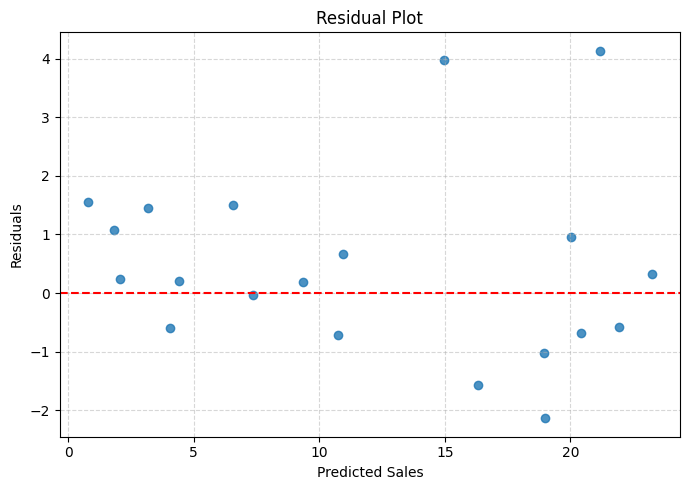

In [140]:
residuals = y_test - y_pred_test
plt.figure(figsize=(7,5))
plt.scatter(y_pred_test, residuals, alpha=0.8)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Sales"); plt.ylabel("Residuals"); plt.title("Residual Plot")
plt.grid(True, linestyle='--', alpha=0.5); plt.tight_layout(); plt.show()

### Dataset Creation

In [141]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### Create synthetic dataset

In [142]:
np.random.seed(42)
n_samples = 200

sqft = np.random.randint(500, 3500, n_samples)
bedrooms = np.random.randint(1, 5, n_samples)
location_factor = np.random.randint(1, 4, n_samples) # 1=Tier3, 2=Tier2, 3=Tier1

#House price formula (with noise)
price = (sqft * 200) + (bedrooms * 50000) + (location_factor * 100000) + np.random.randint(-50000, 50000, n_samples)

# Create a dataframe:
data_reg = pd.DataFrame({
    "sqft": sqft,
    "bedrooms": bedrooms,
    "location_factor": location_factor,
    "price": price
})

In [143]:
data_reg.head()

,sqft,bedrooms,location_factor,price
0,1360,4,2,637305
1,1794,4,1,684153
2,1630,2,2,652797
3,1595,3,1,584953
4,2138,2,2,735058


In [144]:
data_reg.shape

(200, 4)

### Train Regression Model

In [145]:
X = data_reg[["sqft", "bedrooms", "location_factor"]]
y = data_reg["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [146]:
## Train Linear Regression:

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

LinearRegression()

In [147]:
## Predictions:

y_pred = reg_model.predict(X_test)


In [149]:
## Evaluation:

print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 912934338.5509735
RMSE: 30214.80330154366
R2 Score: 0.9714245028543901


### Classification Example: Predicting Customer Churn

In [153]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [155]:
### Create a sample dataset:

np.random.seed(42)

data_class = pd.DataFrame({
    "MonthlyCharges": np.random.randint(500, 2000, 100),
    "Tenure": np.random.randint(1, 60, 100), #months
    "Churn": np.random.randint(0, 2, 100) # 0 = No, 1 = Yes
})

In [156]:
data_class.head()

,MonthlyCharges,Tenure,Churn
0,1626,45,1
1,1959,41,1
2,1360,29,0
3,1794,15,1
4,1630,45,0


In [157]:
### Split into features & Target

X = data_class[["MonthlyCharges", "Tenure"]]
y = data_class["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [158]:
## Train a Logistic Regression Model

clf = LogisticRegression()
clf.fit(X_train, y_train)

LogisticRegression()

In [159]:
### Predictions:

y_pred = clf.predict(X_test)

print("Predictions:", y_pred[:10])

Predictions: [1 0 0 0 1 0 0 0 0 1]


### Evaluation

In [160]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.45


### Confusion Matrix

In [162]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[5 3]
 [8 4]]


### Precision, Recall, F1

In [164]:
print("Classification Report: \n", classification_report(y_test, y_pred))

Classification Report: 
               precision    recall  f1-score   support

           0       0.38      0.62      0.48         8
           1       0.57      0.33      0.42        12

    accuracy                           0.45        20
   macro avg       0.48      0.48      0.45        20
weighted avg       0.50      0.45      0.44        20



### To improve churn classification model: 

1. Data Improvements
2. Deal with Class Imbalances
3. Try with More powerful Models
4. Hyperparameter tuning
5. Better Evaluation Strategy


---

# Practice Exercises

1. **Load a new dataset**: Create a simple CSV file named `practice.csv` with columns `Name`, `Age`, `City` (include some missing values). Load it into a DataFrame.
2. **Missing Value Challenge**: Fill the missing `Age` values in your practice DataFrame with the **median** age instead of the mean.
3. **Duplicate Hunt**: Add a duplicate row to your DataFrame and practice removing it, keeping the **last** occurrence.

---

# 🎊 Congratulations! You've Completed Python for AI!

## 📝 What You've Learned

### ✅ Data Loading & Formats
- **CSV Files:** `pd.read_csv()` - Most common format
- **Excel Files:** `pd.read_excel()` - Business data
- **JSON Files:** `pd.read_json()` - Web APIs

### ✅ Data Cleaning Techniques
- **Missing Value Detection:** `.isna().sum()`
- **Handling Strategies:**
  - Drop: `.dropna()`
  - Fill constant: `.fillna(0)`
  - Forward fill: `.fillna(method='ffill')`
  - Statistical: `.fillna(df.mean())`, `.fillna(df.median())`, `.fillna(df.mode()[0])`
- **Duplicate Removal:** `.drop_duplicates()`
- **Outlier Detection:** IQR method (Q1, Q3, IQR boundaries)
- **Data Type Conversion:** `.astype()`, `pd.to_datetime()`

### ✅ Data Visualization with Matplotlib
- **Line Plots:** Time series trends (`plt.plot()`)
- **Bar Charts:** Categorical comparisons (`plt.bar()`)
- **Histograms:** Distribution analysis (`plt.hist()`)
- **Box Plots:** Outlier visualization (`plt.boxplot()`)
- **Scatter Plots:** Relationship exploration (`plt.scatter()`)

### ✅ Machine Learning Fundamentals
- **Linear Regression:** Predicting continuous values (house prices, sales)
- **Logistic Regression:** Binary classification (churn prediction)
- **Model Workflow:**
  1. Split data: `train_test_split()`
  2. Train model: `model.fit()`
  3. Make predictions: `model.predict()`
  4. Evaluate: R², MSE, RMSE, accuracy, confusion matrix
- **Model Persistence:** Save/load with `joblib`

---

## 🎯 Key Takeaways

### The Data Science Pipeline

```
1. LOAD     →  Read data from various sources
2. INSPECT  →  Understand structure and quality
3. CLEAN    →  Handle missing values, duplicates, outliers
4. TRANSFORM→  Convert types, engineer features
5. VISUALIZE→  Explore patterns and relationships
6. MODEL    →  Train ML algorithms
7. EVALUATE →  Measure performance
8. DEPLOY   →  Save and use in production
```

### 💡 Best Practices

1. **Always Inspect First**
   - Use `.head()`, `.info()`, `.describe()` before processing
   - Check for missing values, duplicates, outliers

2. **Clean Systematically**
   - Missing values → Duplicates → Outliers → Type conversions
   - Document your decisions (why drop vs fill?)

3. **Visualize Before Modeling**
   - Understand distributions (histograms)
   - Detect outliers (box plots)
   - Explore relationships (scatter plots)

4. **Choose the Right Strategy**

| Problem | Solution |
|---------|----------|
| Few missing values (<5%) | Drop rows with `.dropna()` |
| Moderate missing (5-30%) | Impute with mean/median/mode |
| Many missing (>30%) | Consider dropping column |
| Time-series gaps | Forward/backward fill |
| Categorical missing | Fill with mode or 'Unknown' |
| Outliers | IQR method or domain expertise |

5. **Evaluate Properly**
   - **Regression:** R², MSE, RMSE, MAE
   - **Classification:** Accuracy, Precision, Recall, F1-score, Confusion Matrix
   - Always use test set (never evaluate on training data!)

---

## 🚀 Next Steps in Your AI Journey

### Immediate Practice
1. ✅ Complete the practice exercises at the end of this notebook
2. ✅ Load your own dataset and apply the full pipeline
3. ✅ Experiment with different imputation strategies
4. ✅ Create visualizations to tell a data story

### Advanced Topics to Explore
- **Feature Engineering:** Creating new meaningful features
- **Advanced Imputation:** KNN imputation, iterative imputation
- **Advanced Visualizations:** Seaborn, Plotly (interactive)
- **More ML Algorithms:** Decision Trees, Random Forests, Neural Networks
- **Cross-Validation:** More robust model evaluation
- **Hyperparameter Tuning:** Optimizing model performance
- **Deep Learning:** TensorFlow, PyTorch

---

## 📚 Recommended Resources

### Documentation
- [Pandas Official Documentation](https://pandas.pydata.org/docs/)
- [Matplotlib Gallery](https://matplotlib.org/stable/gallery/index.html)
- [Scikit-learn User Guide](https://scikit-learn.org/stable/user_guide.html)

### Books
- "Python for Data Analysis" by Wes McKinney (Pandas creator)
- "Hands-On Machine Learning" by Aurélien Géron
- "Data Science from Scratch" by Joel Grus

### Practice Platforms
- [Kaggle](https://www.kaggle.com) - Datasets and competitions
- [Google Colab](https://colab.research.google.com) - Free cloud notebooks
- [UCI ML Repository](https://archive.ics.uci.edu/ml/) - Classic datasets

---

## 🎓 Final Wisdom

> "Data is the new oil, but like oil, it needs to be refined before it becomes valuable." 
> — Clive Humby

> "In God we trust. All others must bring data."
> — W. Edwards Deming

**Remember:** 
- 🔑 Data quality determines model quality
- 📊 Visualization reveals insights that numbers hide
- 🎯 The best model is useless with bad data
- 💪 Practice makes perfect - keep coding!

---

**You're now equipped to:**
- ✅ Clean and prepare real-world datasets
- ✅ Create professional visualizations
- ✅ Build and evaluate machine learning models
- ✅ Contribute to AI projects

**Keep learning, keep experimenting, and welcome to the world of AI!** 🎊🤖✨
